In [1]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

# Clone YOLOv9 repository
!git clone https://github.com/WongKinYiu/yolov9.git
%cd yolov9

# Install required packages
!pip install -r requirements.txt


Cloning into 'yolov9'...
remote: Enumerating objects: 781, done.
remote: Total 781 (delta 0), reused 0 (delta 0), pack-reused 781 (from 1)
Receiving objects: 100% (781/781), 3.27 MiB | 13.67 MiB/s, done.
Resolving deltas: 100% (330/330), done.
/content/yolov9
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.1 MB/s eta 0:00:00


In [4]:
!mkdir -p weights
!wget -P ./weights https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt


--2026-03-10 20:22:38--  https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/759338070/c8ca43f2-0d2d-4aa3-a074-426505bfbfb1?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-10T21%3A01%3A43Z&rscd=attachment%3B+filename%3Dyolov9-c.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-10T20%3A01%3A23Z&ske=2026-03-10T21%3A01%3A43Z&sks=b&skv=2018-11-09&sig=tvftfBWXsB8FTb1wMBQ2M%2FJkWyje3DXa2ZjhM0go1qg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzE3NTk1OCwibmJmIjoxNzczMTc0MTU4LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNv

In [5]:
!pip install -q "albumentations==1.3.1"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 13.4 MB/s eta 0:00:00


In [6]:
import yaml

dataset_dir = '/content/drive/MyDrive/VOC_PCB/yolo_ready'
yaml_path = f'{dataset_dir}/dataset.yaml'

data = {
    'train': f'{dataset_dir}/images/train',
    'val': f'{dataset_dir}/images/val',
    'test': f'{dataset_dir}/images/test',
    'nc': 6,
    'names': ['missing hole', 'mouse bite', 'open circuit', 'short', 'spur', 'spurious copper']
}

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)


In [7]:
# Fix for PyTorch >= 2.6: patch train_dual.py on disk so the subprocess picks it up
import re

with open('/content/yolov9/train_dual.py', 'r') as f:
    content = f.read()

# Add weights_only=False to every torch.load(...) call that doesn't already have it
patched = re.sub(
    r'torch\.load\(([^)]+)\)',
    lambda m: m.group(0) if 'weights_only' in m.group(0)
              else f"torch.load({m.group(1)}, weights_only=False)",
    content
)

with open('/content/yolov9/train_dual.py', 'w') as f:
    f.write(patched)

print('✅ train_dual.py patched: weights_only=False added to all torch.load() calls')


✅ train_dual.py patched: weights_only=False added to all torch.load() calls


In [8]:
%cd /content/yolov9

!python train_dual.py \
  --workers 8 \
  --device 0 \
  --batch 16 \
  --data /content/drive/MyDrive/VOC_PCB/yolo_ready/dataset.yaml \
  --img 640 \
  --cfg models/detect/yolov9-c.yaml \
  --weights ./weights/yolov9-c.pt \
  --name yolov9-voc-pcb \
  --hyp hyp.scratch-high.yaml \
  --min-items 0 \
  --epochs 100 \
  --close-mosaic 15


/content/yolov9
2026-03-10 20:23:04.478296: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 20:23:04.496794: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773174184.519532   10657 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773174184.526926   10657 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773174184.546216   10657 computation_placer.cc:177] computation placer already registered. Please check linkage an

In [9]:
# Copy the results from Colab VM to your personal Google Drive
!mkdir -p /content/drive/MyDrive/VOC_PCB/yolo_results
# Copy the entire yolov9-voc-pcb folder (which includes the /weights folder, best.pt, last.pt, and all graphs) to your newly created Drive folder
!cp -r /content/yolov9/runs/train/yolov9-voc-pcb /content/drive/MyDrive/VOC_PCB/yolo_results/
print("✅ All weights, graphs, and results have been successfully backed up to Google Drive!")



✅ All weights, graphs, and results have been successfully backed up to Google Drive!


In [ ]:
# The bottom code is just for testing the trained model on the test set and visualizing the results. You can run it after training is complete.

[l_light_04_spurious_copper_10_1_600.jpg] found 1 bounding boxes.
[rotation_270_light_11_short_09_1_600.jpg] found 3 bounding boxes.
[rotation_270_light_08_open_circuit_02_1_600.jpg] found 2 bounding boxes.


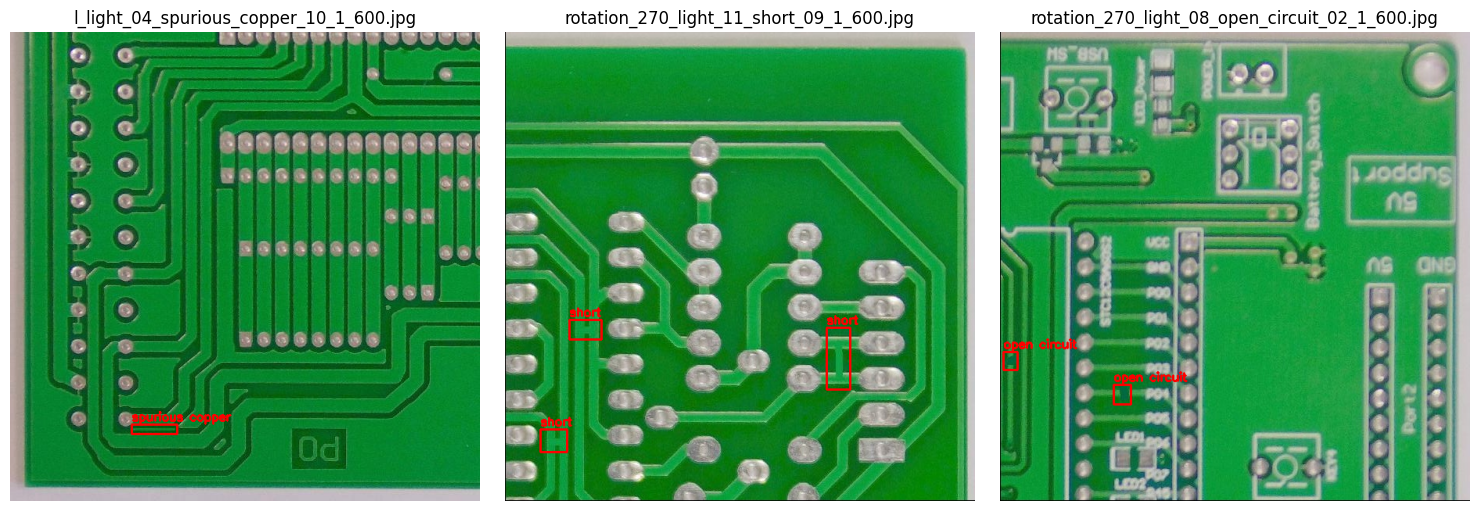

In [10]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Paths to your images and labels
img_dir = '/content/drive/MyDrive/VOC_PCB/yolo_ready/images/train'
label_dir = '/content/drive/MyDrive/VOC_PCB/yolo_ready/labels/train'

# Class names defined in your dataset.yaml
class_names = ['missing hole', 'mouse bite', 'open circuit', 'short', 'spur', 'spurious copper']

def check_bounding_boxes():
    # Get all images
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    if not img_files:
        print("No .jpg images found in", img_dir)
        return

    # Pick 3 random images to check
    selected_imgs = random.sample(img_files, min(3, len(img_files)))

    plt.figure(figsize=(15, 5))
    
    for idx, img_name in enumerate(selected_imgs):
        # Image and label paths
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt'))
        
        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        # Check if label file exists
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                
            print(f"[{img_name}] found {len(lines)} bounding boxes.")
            
            # Draw each box
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    # YOLO format: x_center, y_center, width, height (normalized)
                    x_center, y_center, box_w, box_h = map(float, parts[1:5])
                    
                    # Convert to pixel coordinates
                    x1 = int((x_center - box_w/2) * w)
                    y1 = int((y_center - box_h/2) * h)
                    x2 = int((x_center + box_w/2) * w)
                    y2 = int((y_center + box_h/2) * h)
                    
                    # Draw rectangle
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    
                    # Add label text
                    if class_id < len(class_names):
                        label_text = class_names[class_id]
                        cv2.putText(img, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        else:
            print(f"[{img_name}] No label file found!")

        # Display image
        plt.subplot(1, len(selected_imgs), idx + 1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the check
check_bounding_boxes()


In [11]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Class names defined in your dataset.yaml
class_names = ['missing hole', 'mouse bite', 'open circuit', 'short', 'spur', 'spurious copper']

def calculate_iou(box1, box2):
    # box format: [x1, y1, x2, y2]
    # Calculate intersection
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # Calculate union
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area if union_area > 0 else 0.0

def process_dataset_split(split='train'):
    base_dir = '/content/drive/MyDrive/VOC_PCB/yolo_ready'
    img_dir = f'{base_dir}/images/{split}'
    label_dir = f'{base_dir}/labels/{split}'
    output_dir = f'{base_dir}/visualized/{split}'
    
    os.makedirs(output_dir, exist_ok=True)
    
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    if not img_files:
        print(f"No images found in {img_dir}")
        return

    print(f"Processing {len(img_files)} images in {split} split...")
    
    for img_name in tqdm(img_files):
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt'))
        
        img = cv2.imread(img_path)
        if img is None: continue
        h, w, _ = img.shape
        
        # Ground truth boxes
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    # YOLO format: x_center, y_center, width, height (normalized)
                    x_center, y_center, box_w, box_h = map(float, parts[1:5])
                    
                    # Convert to pixel coordinates
                    x1 = int((x_center - box_w/2) * w)
                    y1 = int((y_center - box_h/2) * h)
                    x2 = int((x_center + box_w/2) * w)
                    y2 = int((y_center + box_h/2) * h)
                    
                    # Draw green rectangle for ground truth
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    
                    if class_id < len(class_names):
                        label_text = class_names[class_id]
                        cv2.putText(img, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        # Save visualization
        output_path = os.path.join(output_dir, img_name)
        cv2.imwrite(output_path, img)

# Run for all splits
process_dataset_split('train')
process_dataset_split('val')
process_dataset_split('test')

print("✅ Visualization complete! Check the 'visualized' folder on your Drive.")


Processing 5120 images in train split...


100%|██████████| 5120/5120 [1:49:05<00:00,  1.28s/it]  


Processing 3414 images in val split...


100%|██████████| 3414/3414 [1:13:33<00:00,  1.29s/it]


Processing 2134 images in test split...


100%|██████████| 2134/2134 [1:39:42<00:00,  2.80s/it]  

✅ Visualization complete! Check the 'visualized' folder on your Drive.


In [ ]:
import pandas as pd
import os

csv_path = '/content/drive/MyDrive/VOC_PCB/yolo_results/results.csv' # Update this path if different!

if os.path.exists(csv_path):
    # YOLO results.csv has columns like: epoch, train/box_loss, train/obj_loss, ...
    # We strip whitespace from column names because YOLO formats them strangely
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    
    total_epochs = len(df)
    print(f"✅ Found results.csv! Your training completed {total_epochs} epochs.")
    
    if total_epochs > 0:
        last_epoch = df.iloc[-1]
        print("\nmetrics from the LAST epoch:")
        
        # safely print map@0.5 if it exists
        map50_col = [c for c in df.columns if 'mAP_0.5' in c or 'mAP@.5' in c or 'metrics/mAP50' in c]
        if map50_col:
            print(f"• Final mAP@0.5: {last_epoch[map50_col[0]]:.4f}")
            
        print(f"• Box Loss: {last_epoch.get('train/box_loss', 'N/A')}")
        print(f"• Obj Loss: {last_epoch.get('train/obj_loss', 'N/A')}")
        
    if total_epochs >= 100:
        print("\n🎉 Your training finished all 100 epochs!")
    else:
        print(f"\n⚠️ The training crashed or was stopped early at epoch {total_epochs}.")
else:
    print(f"❌ Could not find {csv_path}. Make sure the path is correct!")


In [13]:
# Check if training actually made a weights folder in Colab:
!ls -la /content/yolov9/runs/train/yolov9-voc-pcb/weights/

# Check if you successfully copied it to your Google Drive:
!ls -la /content/drive/MyDrive/VOC_PCB/yolo_results/weights/


total 800416
drwxr-xr-x 2 root root      4096 Mar 10 20:58 .
drwxr-xr-x 3 root root      4096 Mar 10 20:58 ..
-rw-r--r-- 1 root root 409807645 Mar 11 07:32 best.pt
-rw-r--r-- 1 root root 409807645 Mar 11 07:32 last.pt
total 0


In [19]:
# Fix for PyTorch >= 2.6: carefully patch attempt_download in experimental.py
import os

filepath = '/content/yolov9/models/experimental.py'

if os.path.exists(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    # Fix the broken line if it got patched incorrectly last time
    content = content.replace("ckpt = torch.load(attempt_download(w, weights_only=False), map_location='cpu')",
                              "ckpt = torch.load(attempt_download(w), map_location='cpu', weights_only=False)")
                              
    # Also fix it if it hasn't been patched at all yet
    content = content.replace("ckpt = torch.load(attempt_download(w), map_location='cpu')",
                              "ckpt = torch.load(attempt_download(w), map_location='cpu', weights_only=False)")

    with open(filepath, 'w') as f:
        f.write(content)
    print(f'✅ Successfully correctly patched {filepath}')



✅ Successfully correctly patched /content/yolov9/models/experimental.py


In [20]:
%cd /content/yolov9

print("==== RUNNING VAL SPLIT ====")
# 1. Evaluate on Validation Set
!python val_dual.py \
  --data /content/drive/MyDrive/VOC_PCB/yolo_ready/dataset.yaml \
  --img 640 \
  --batch 16 \
  --conf 0.001 \
  --iou 0.65 \
  --device 0 \
  --weights /content/drive/MyDrive/VOC_PCB/yolo_results/yolov9-voc-pcb/weights/best.pt \
  --task val \
  --name yolov9-voc-pcb-val 

print("\n==== RUNNING TEST SPLIT ====")
# 2. Evaluate on Test Set
!python val_dual.py \
  --data /content/drive/MyDrive/VOC_PCB/yolo_ready/dataset.yaml \
  --img 640 \
  --batch 16 \
  --conf 0.001 \
  --iou 0.65 \
  --device 0 \
  --weights /content/drive/MyDrive/VOC_PCB/yolo_results/yolov9-voc-pcb/weights/best.pt \
  --task test \
  --name yolov9-voc-pcb-test

print("\n==== SAVING EVALUATION RESULTS TO DRIVE ====")
# 3. Copy both evaluation folders to your Drive permanently (Optional, saving it to where the weights are)
!cp -r /content/yolov9/runs/val/yolov9-voc-pcb-val /content/drive/MyDrive/VOC_PCB/yolo_results/yolov9-voc-pcb/eval_val
!cp -r /content/yolov9/runs/val/yolov9-voc-pcb-test /content/drive/MyDrive/VOC_PCB/yolo_results/yolov9-voc-pcb/eval_test

print("✅ All evaluation metrics (including IoU/mAP) for both Val and Test sets are saved in your Drive!")


/content/yolov9
==== RUNNING VAL SPLIT ====
val_dual: data=/content/drive/MyDrive/VOC_PCB/yolo_ready/dataset.yaml, weights=['/content/drive/MyDrive/VOC_PCB/yolo_results/yolov9-voc-pcb/weights/best.pt'], batch_size=16, imgsz=640, conf_thres=0.001, iou_thres=0.65, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=yolov9-voc-pcb-val, exist_ok=False, half=False, dnn=False, min_items=0
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)

Fusing layers... 
yolov9-c summary: 604 layers, 50709828 parameters, 0 gradients, 236.7 GFLOPs
val: Scanning /content/drive/MyDrive/VOC_PCB/yolo_ready/labels/val.cache... 3414 images, 0 backgrounds, 0 corrupt: 100% 3414/3414 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:   0% 1/214 [00:01<05:16,  1.48s/it]Exception in thread Thread

In [22]:
!echo "=== Model Weights ===" && ls /content/drive/MyDrive/VOC_PCB/yolo_results/yolov9-voc-pcb/weights/
!echo "=== Val Evaluation Results ===" && ls /content/drive/MyDrive/VOC_PCB/yolo_results/eval_val/
!echo "=== Test Evaluation Results ===" && ls /content/drive/MyDrive/VOC_PCB/yolo_results/eval_test/


=== Model Weights ===
best.pt  last.pt
=== Val Evaluation Results ===
=== Test Evaluation Results ===


In [23]:
# First, check what evaluation folders actually got created
!ls /content/yolov9/runs/val/


yolov9-voc-pcb-test   yolov9-voc-pcb-test5  yolov9-voc-pcb-val3
yolov9-voc-pcb-test2  yolov9-voc-pcb-test6  yolov9-voc-pcb-val4
yolov9-voc-pcb-test3  yolov9-voc-pcb-val    yolov9-voc-pcb-val5
yolov9-voc-pcb-test4  yolov9-voc-pcb-val2   yolov9-voc-pcb-val6


In [24]:
# Copy ALL val results to Drive (replace the folder names with whatever you saw above)
!cp -r /content/yolov9/runs/val/ /content/drive/MyDrive/VOC_PCB/yolo_results/eval_all/
print("✅ All evaluation results saved!")


✅ All evaluation results saved!


In [25]:
# Copy the most recent (latest) val and test results to Drive
!cp -r /content/yolov9/runs/val/yolov9-voc-pcb-val6 /content/drive/MyDrive/VOC_PCB/yolo_results/eval_val/
!cp -r /content/yolov9/runs/val/yolov9-voc-pcb-test6 /content/drive/MyDrive/VOC_PCB/yolo_results/eval_test/
print("✅ Evaluation results saved!")


✅ Evaluation results saved!


In [26]:
!echo "=== Training Results ===" && ls /content/drive/MyDrive/VOC_PCB/yolo_results/yolov9-voc-pcb/
!echo "=== Val Eval ===" && ls /content/drive/MyDrive/VOC_PCB/yolo_results/eval_val/
!echo "=== Test Eval ===" && ls /content/drive/MyDrive/VOC_PCB/yolo_results/eval_test/


=== Training Results ===
eval_test					     labels.jpg
eval_val					     opt.yaml
events.out.tfevents.1773174221.bd9fa09fcd9a.10657.0  results.csv
hyp.yaml					     weights
labels_correlogram.jpg
=== Val Eval ===
yolov9-voc-pcb-val6
=== Test Eval ===
yolov9-voc-pcb-test6
